<a href="https://colab.research.google.com/github/x1001000/Colab-Notebooks/blob/main/%E7%94%A8_Gemini_API_gemini_3_flash_preview_%E6%A8%A1%E5%9E%8B%E7%9C%8B%E5%9C%96%E6%89%80%E9%9C%80%E7%9A%84%E6%99%82%E9%96%93%E5%8F%8A%E8%B2%BB%E7%94%A8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Gemini API 文件
https://ai.google.dev/gemini-api/docs/image-understanding

# 以這張預覽圖為例
https://cdn.macromicro.me/files/charts/592/592-tc.png

In [1]:
import requests
r = requests.get('https://cdn.macromicro.me/files/charts/592/592-tc.png')

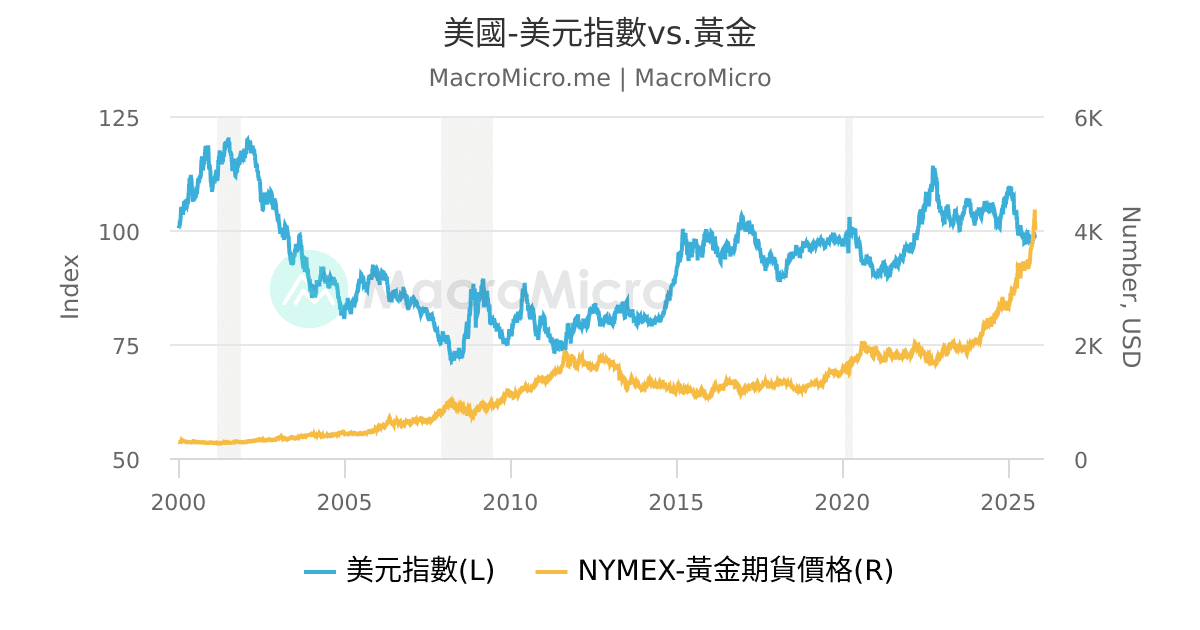

In [2]:
from IPython.display import Image
Image(data=r.content)

In [3]:
from google import genai
from google.genai import types

client = genai.Client()

import time
start = time.time()
response = client.models.generate_content(
    model="gemini-3-flash-preview",
    contents=[
      types.Part.from_bytes(
        data=r.content,
        mime_type='image/jpeg',
      ),
      '解說'
    ]
)
end = time.time()
print(f'時間約{end-start:.0f}s\n\n')

cost = (
    response.usage_metadata.prompt_token_count * 0.5 +
    response.usage_metadata.candidates_token_count * 3 +
    (response.usage_metadata.cached_content_token_count or 0) * 0.05 +
    (response.usage_metadata.thoughts_token_count or 0) * 3) / 1e6
print(f'費用約{cost * 31.57:.2f}twd（圖片輸入tokens約{response.usage_metadata.prompt_token_count}個）\n\n')

print(response.text)

時間約13s


費用約0.19twd（圖片輸入tokens約1107個）


這張圖表來自財經數據平台 MacroMicro（財經M平方），呈現了過去 25 年（2000年至約 2025 年）**美元指數（US Dollar Index）**與**黃金期貨價格（Gold Futures）**之間的走勢對比與關係。

以下是詳細的解說：

### 1. 圖表基本資訊
*   **藍色線（左軸 L）：** 美元指數。衡量美元兌一籃子主要貨幣匯率的指標。數值越高代表美元越強勢。
*   **黃色線（右軸 R）：** NYMEX-黃金期貨價格。單位為美元。
*   **灰色陰影區：** 代表美國經濟衰退期（如 2001 年科技泡沫、2008 年金融海嘯、2020 年新冠疫情）。

---

### 2. 核心邏輯：傳統的「負相關」關係
在大多數歷史時期，美元與黃金呈現明顯的**負相關（即走勢相反）**：
*   **原因一：定價效應。** 黃金在全球市場是以美元計價的。當美元貶值（藍線下跌），用美元買黃金變得更便宜，推升金價；反之，美元升值時，金價通常承壓。
*   **原因二：替代投資。** 美元與黃金同為避險資產，但美元有利息（或債券收益），黃金則沒有。當美國經濟強勁或利率上升導致美元走強時，資金傾向流向美元；當市場對貨幣體系失去信心或美元走弱時，資金流向黃金避險。

**歷史實例：**
*   **2002-2008年：** 美元進入大空頭（藍線大跌），黃金則迎來一波長達數年的大牛市（黃線穩步上升）。
*   **2011-2015年：** 美元開始回升，金價則經歷了大幅回檔與盤整。

---

### 3. 近年來的「脫鉤」現象（值得關注的重點）
觀察圖表最右側（約 2022 年至今），可以發現一個特殊的現象：**美元指數與黃金同時維持在高位，甚至同步上漲。**

這代表傳統的負相關邏輯正在減弱，背後原因可能包括：
1.  **地緣政治風險：** 俄烏戰爭、中東衝突等緊張局勢，讓市場同時追求美元（流動性避險）與黃金（終極避險）。
2.  **各國央行購金：** 許多國家央行（尤其是中國、俄羅斯等）為了「去美元化」，即便美元強勁，仍大量增加黃金儲備。
3.  **通膨預期：** 儘管聯準會升息拉高了美元，但市場長期對通膨與政府債務規模感到擔憂，持續買入黃金保值。

